In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error, classification_report

In [2]:
dt = pd.read_csv("data.csv")

In [3]:
dt

,Frequency,Total_Donation,Recency,Readiness,Availability,Rate,Available_Now
0,50,12500,2,Ready After 1 Month,6.122449,1.960000,NO
1,13,3250,0,Ready After 3 Months,5.571429,2.153846,NO
2,16,4000,1,Ready After 2 Months,5.485714,2.187500,NO
3,20,5000,2,Ready After 1 Month,5.333333,2.250000,NO
4,24,6000,1,Ready After 2 Months,3.740260,3.208333,Yes
...,...,...,...,...,...,...,...
743,2,500,23,Ready,0.631579,19.000000,Yes
744,2,500,21,Ready,0.461538,26.000000,Yes
745,3,750,23,Ready,0.580645,20.666667,Yes
746,1,250,39,Ready,0.307692,39.000000,Yes


In [4]:
dt.columns

Index(['Frequency', 'Total_Donation', 'Recency', 'Readiness', 'Availability',
       'Rate', 'Available_Now'],
      dtype='object')

In [5]:
# 'Frequency', 'Total_Donation', 'Recency', 'Readiness'(cat), 'Availability',     
# 'Rate', 'Available_Now'(cat)


# basic diagnosis
dt.info()  # no missing value
a = dt.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Frequency       748 non-null    int64  
 1   Total_Donation  748 non-null    int64  
 2   Recency         748 non-null    int64  
 3   Readiness       748 non-null    object 
 4   Availability    748 non-null    float64
 5   Rate            748 non-null    float64
 6   Available_Now   748 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 41.0+ KB


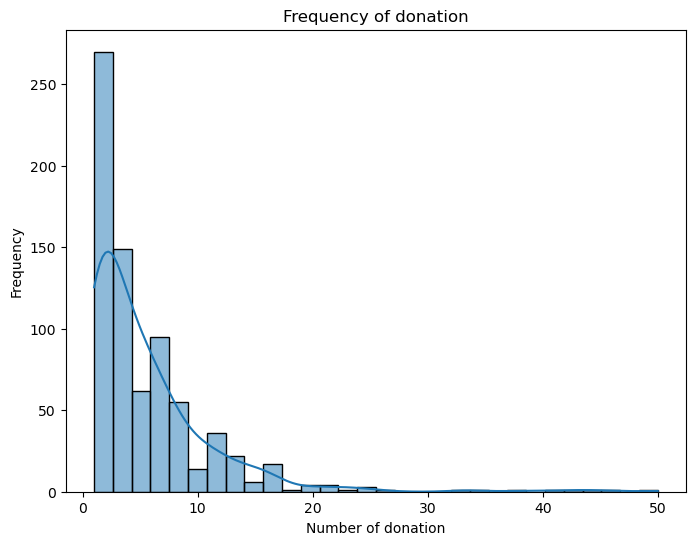

In [6]:
#%%%%

# 2. Histogram for 'Frequency' column 
plt.figure(figsize=(8, 6)) 
sns.histplot(data=dt, x='Frequency', kde=True, bins=30) 
plt.title('Frequency of donation') 
plt.xlabel('Number of donation') 
plt.ylabel('Frequency') 
plt.show()

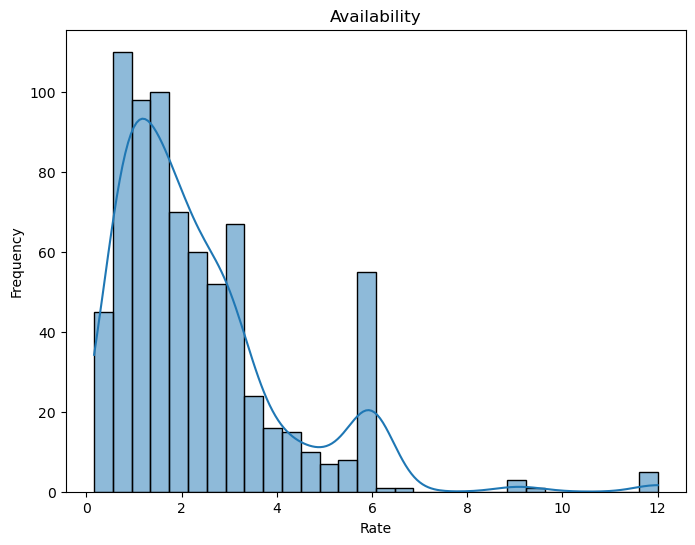

In [7]:
# 2. Histogram for 'Availability' column 
plt.figure(figsize=(8, 6)) 
sns.histplot(data=dt, x='Availability', kde=True, bins=30) 
plt.title('Availability') 
plt.xlabel('Rate') 
plt.ylabel('Frequency') 
plt.show()

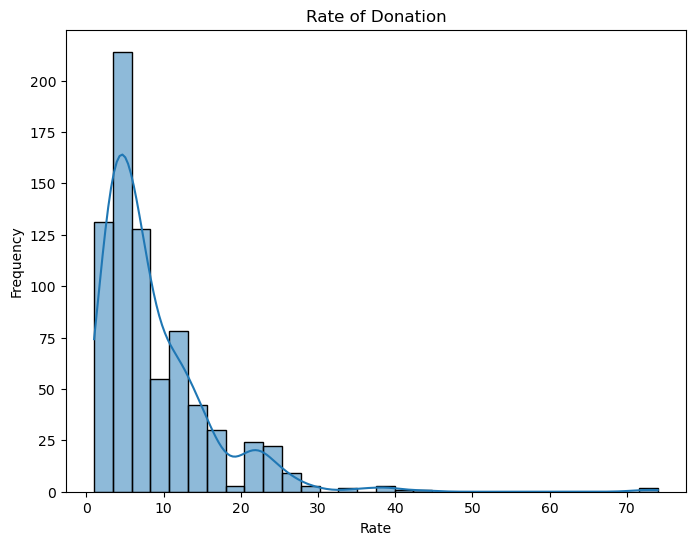

In [8]:
# 2. Histogram for 'Rate' column 
plt.figure(figsize=(8, 6)) 
sns.histplot(data=dt, x='Rate', kde=True, bins=30) 
plt.title('Rate of Donation') 
plt.xlabel('Rate') 
plt.ylabel('Frequency') 
plt.show()

In [9]:
#%%
# categorical data visualization, Readiness
dt['Readiness'].value_counts()
data = [551, 170 ,  19, 8]
labels = ['Ready', 'Ready After 1 Month', 'Ready After 2 Months', 'Ready After 3 Months']
colors = sns.color_palette('pastel')[0:5]


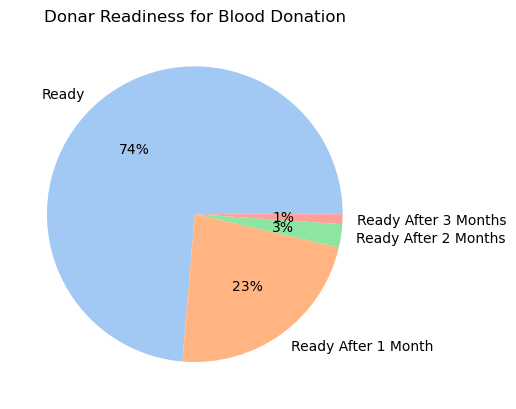

In [10]:
#create pie chart
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.title("Donar Readiness for Blood Donation")
plt.show()

In [11]:
#%%
# categorical data visualization, Available Now
dt['Available_Now'].value_counts()
data = [662, 86 ]
labels = ['Yes', 'No']
colors = sns.color_palette('pastel')[2:4]

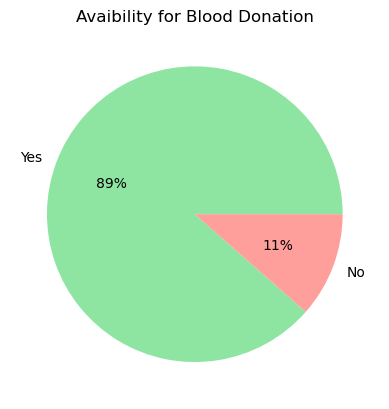

In [12]:
#create pie chart
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.title("Avaibility for Blood Donation")
plt.show()

In [13]:
#%%
# removing outliers for 'Frequency', 'Total_Donation', 'Availability', 'Rate', 'Recency'
# Frequency
dt['Frequency'].value_counts()
dt['Frequency'].mean()
d1 = dt['Frequency'].where(dt['Frequency'] < 30)
d1.value_counts()
nan = np.nan
d1 = pd.DataFrame(d1)
d1['Frequency'].fillna(dt['Frequency'].mean(), inplace=True)
d1['Frequency'].describe()

count    748.000000
mean       5.133847
std        4.477628
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       26.000000
Name: Frequency, dtype: float64

In [14]:
# Total_Donation
dt['Total_Donation'].value_counts()
dt['Total_Donation'].mean()
d2 = dt['Total_Donation'].where(dt['Total_Donation'] < 5000)
d2.value_counts()
d2 = pd.DataFrame(d2)
d2['Total_Donation'].fillna(dt['Total_Donation'].mean(), inplace=True)

In [15]:
# Availability
dt['Availability'].value_counts()
dt['Availability'].mean()
d3 = dt['Availability'].where(dt['Availability'] < 7)
d3.value_counts()
d3 = pd.DataFrame(d3)
d3['Availability'].fillna(dt['Availability'].mean(), inplace=True)

In [16]:
# Rate
dt['Rate'].value_counts()
dt['Rate'].mean()
d4 = dt['Rate'].where(dt['Rate'] < 30)
d4.value_counts()
d4 = pd.DataFrame(d4)
d4['Rate'].fillna(dt['Rate'].mean(), inplace=True)

In [17]:
# Recency
dt['Recency'].value_counts()
dt['Recency'].mean()
d5 = dt['Recency'].where(dt['Recency'] < 10)
d5.value_counts()
d5 = pd.DataFrame(d5)
d5['Recency'].fillna(8, inplace=True)

In [18]:
# new dataframe with all features
frames = [d1, d2, d3, d4,d5,  dt['Readiness'], dt['Available_Now']]
df = pd.concat(frames, axis =1)
df.columns

Index(['Frequency', 'Total_Donation', 'Availability', 'Rate', 'Recency',
       'Readiness', 'Available_Now'],
      dtype='object')

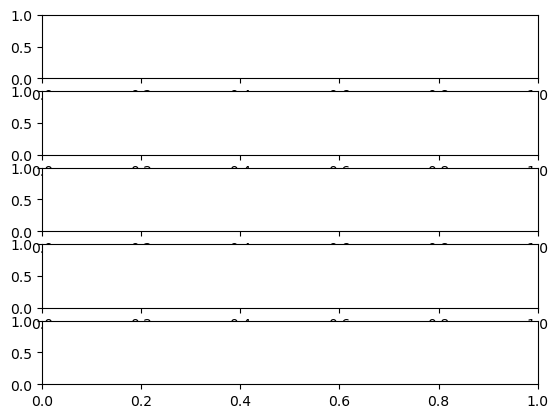

In [19]:
#%%
# univariate normality test
# using histogram
fig, ax = plt.subplots(nrows=5, ncols=1)


In [20]:
ax[0].hist(df['Frequency'], 50,density=True, histtype='bar')
ax[0].set_title('Frequency Histogram')

Text(0.5, 1.0, 'Frequency Histogram')

In [21]:
ax[1].hist(df['Total_Donation'], 50,density=True, histtype='bar')
ax[1].set_title('Total Donation Histogram')

Text(0.5, 1.0, 'Total Donation Histogram')

In [22]:
ax[2].hist(df['Recency'], 50,density=True, histtype='bar')
ax[2].set_title('Recency Histogram')

Text(0.5, 1.0, 'Recency Histogram')

In [23]:
ax[3].hist(df['Availability'], 50,density=True, histtype='bar')
ax[3].set_title('Availability Histogram')

Text(0.5, 1.0, 'Availability Histogram')

In [24]:
ax[4].hist(df['Rate'], 50,density=True, histtype='bar')
ax[4].set_title('Rate Histogram')

Text(0.5, 1.0, 'Rate Histogram')

In [25]:
#fig.tight_layout()
plt.subplots_adjust(hspace=2) 
#plt.autoscale()
plt.show()

<Figure size 640x480 with 0 Axes>

array([[<Axes: title={'center': 'Frequency'}>,
        <Axes: title={'center': 'Total_Donation'}>],
       [<Axes: title={'center': 'Availability'}>,
        <Axes: title={'center': 'Rate'}>],
       [<Axes: title={'center': 'Recency'}>, <Axes: >]], dtype=object)

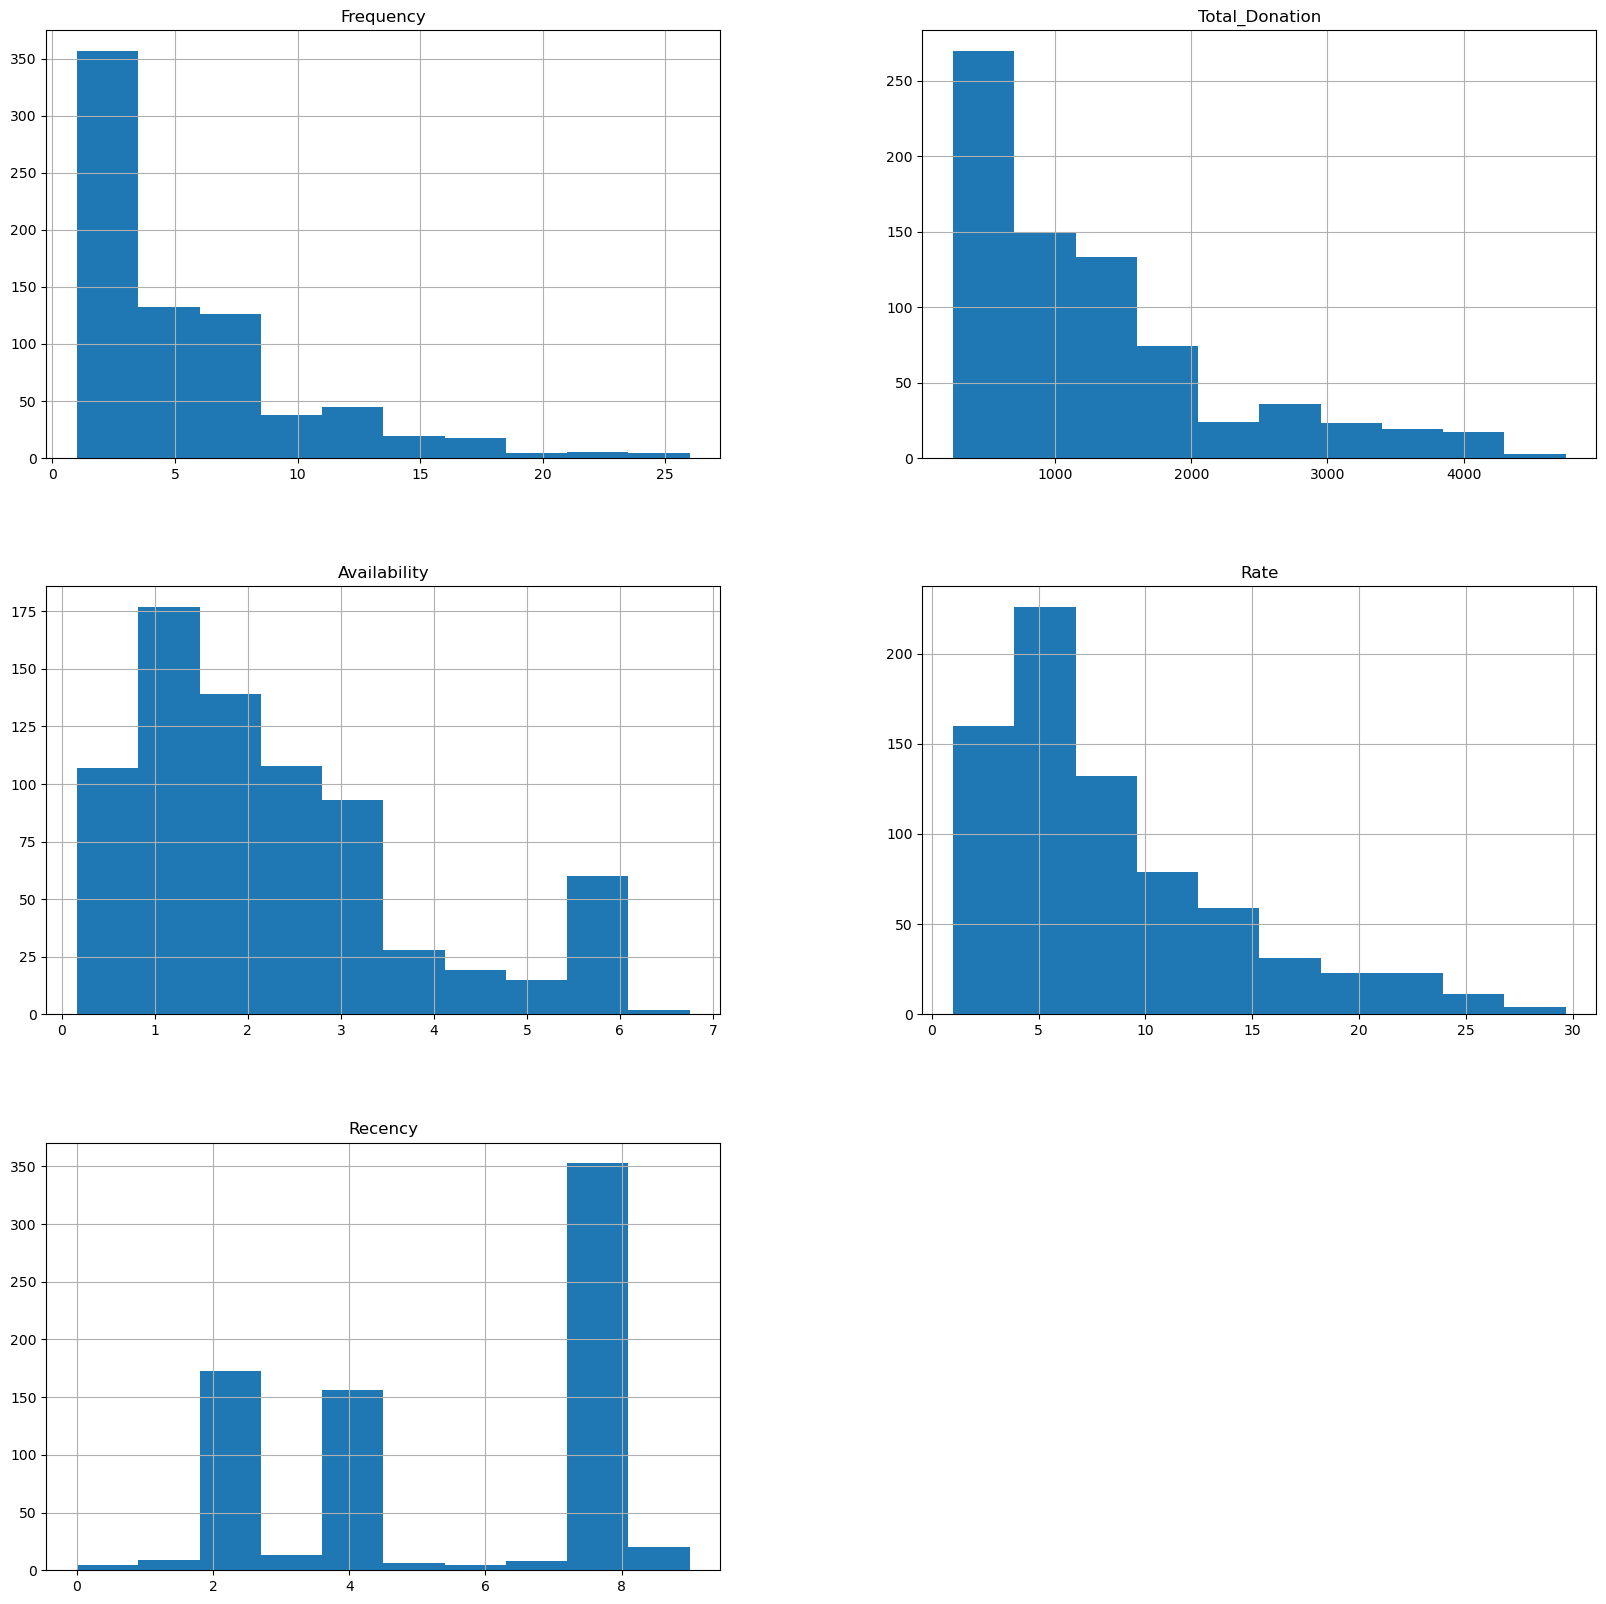

In [26]:
df.hist(figsize=(20,20))

Frequency            Axes(0.125,0.11;0.133621x0.77)
Total_Donation    Axes(0.285345,0.11;0.133621x0.77)
Availability       Axes(0.44569,0.11;0.133621x0.77)
Rate              Axes(0.606034,0.11;0.133621x0.77)
Recency           Axes(0.766379,0.11;0.133621x0.77)
dtype: object

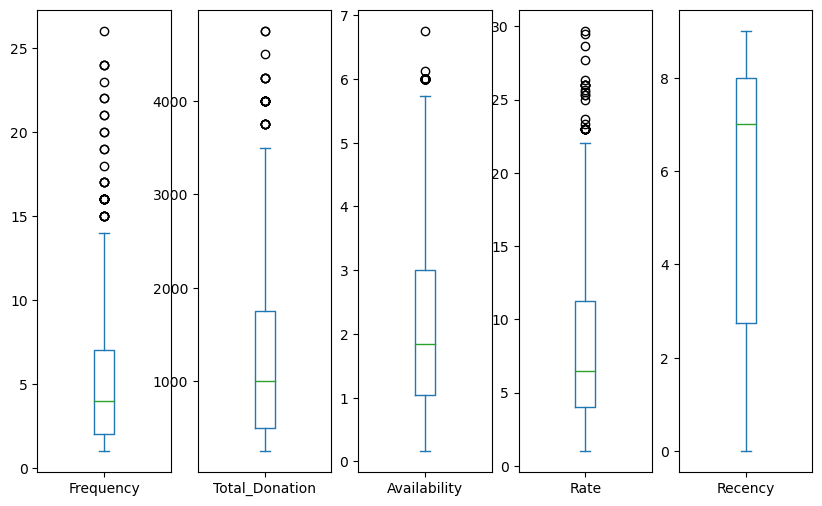

In [27]:
#%%
# box plot
dt1 = df[['Frequency', 'Total_Donation', 'Availability', 'Rate', 'Recency']]
dt1.plot(kind='box', subplots=True, sharey=False, figsize=(10,6))


In [28]:
plt.subplots_adjust(wspace=0.5) 
plt.show()


<Figure size 640x480 with 0 Axes>

In [29]:
# Let's 3d plot the data
ypoint = df['Frequency']
xpoint = df['Total_Donation']
zpoint = df['Availability']

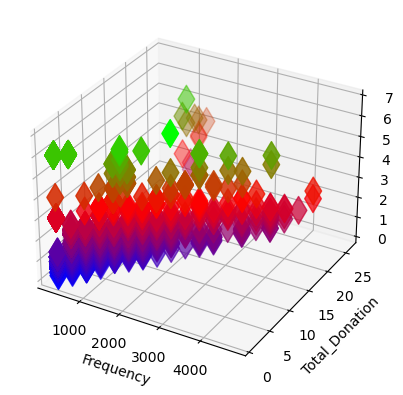

In [30]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('Frequency')
ax.set_ylabel('Total_Donation')
ax.set_zlabel('Availability');
ax.scatter3D(xpoint, ypoint, zpoint, c=zpoint, s = 200, marker="d", cmap='brg');

In [31]:
plt.pause(5.06)
plt.show()

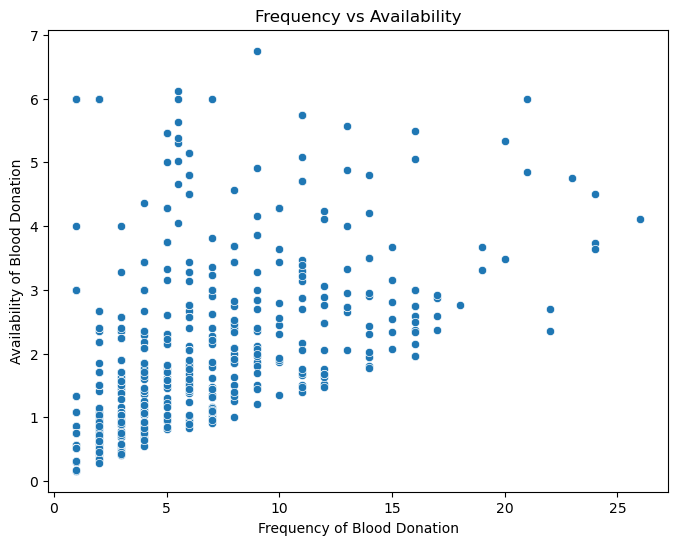

In [32]:
#%%%%%
# scatter plot
# frequency vs availability
plt.figure(figsize=(8, 6)) 
sns.scatterplot(data=df, x='Frequency', y='Availability') 
plt.title('Frequency vs Availability') 
plt.xlabel('Frequency of Blood Donation') 
plt.ylabel('Availability of Blood Donation') 
plt.show() 

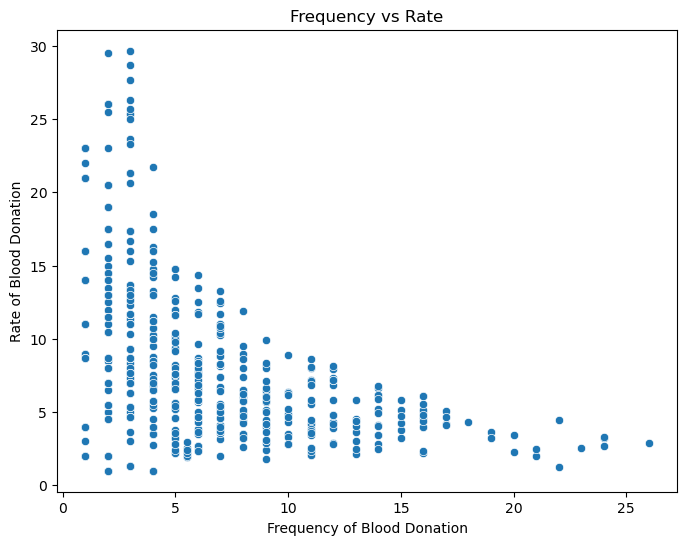

In [33]:
# frequency VS rate
plt.figure(figsize=(8, 6)) 
sns.scatterplot(data=df, x='Frequency', y='Rate') 
plt.title('Frequency vs Rate') 
plt.xlabel('Frequency of Blood Donation') 
plt.ylabel('Rate of Blood Donation') 
plt.show() 


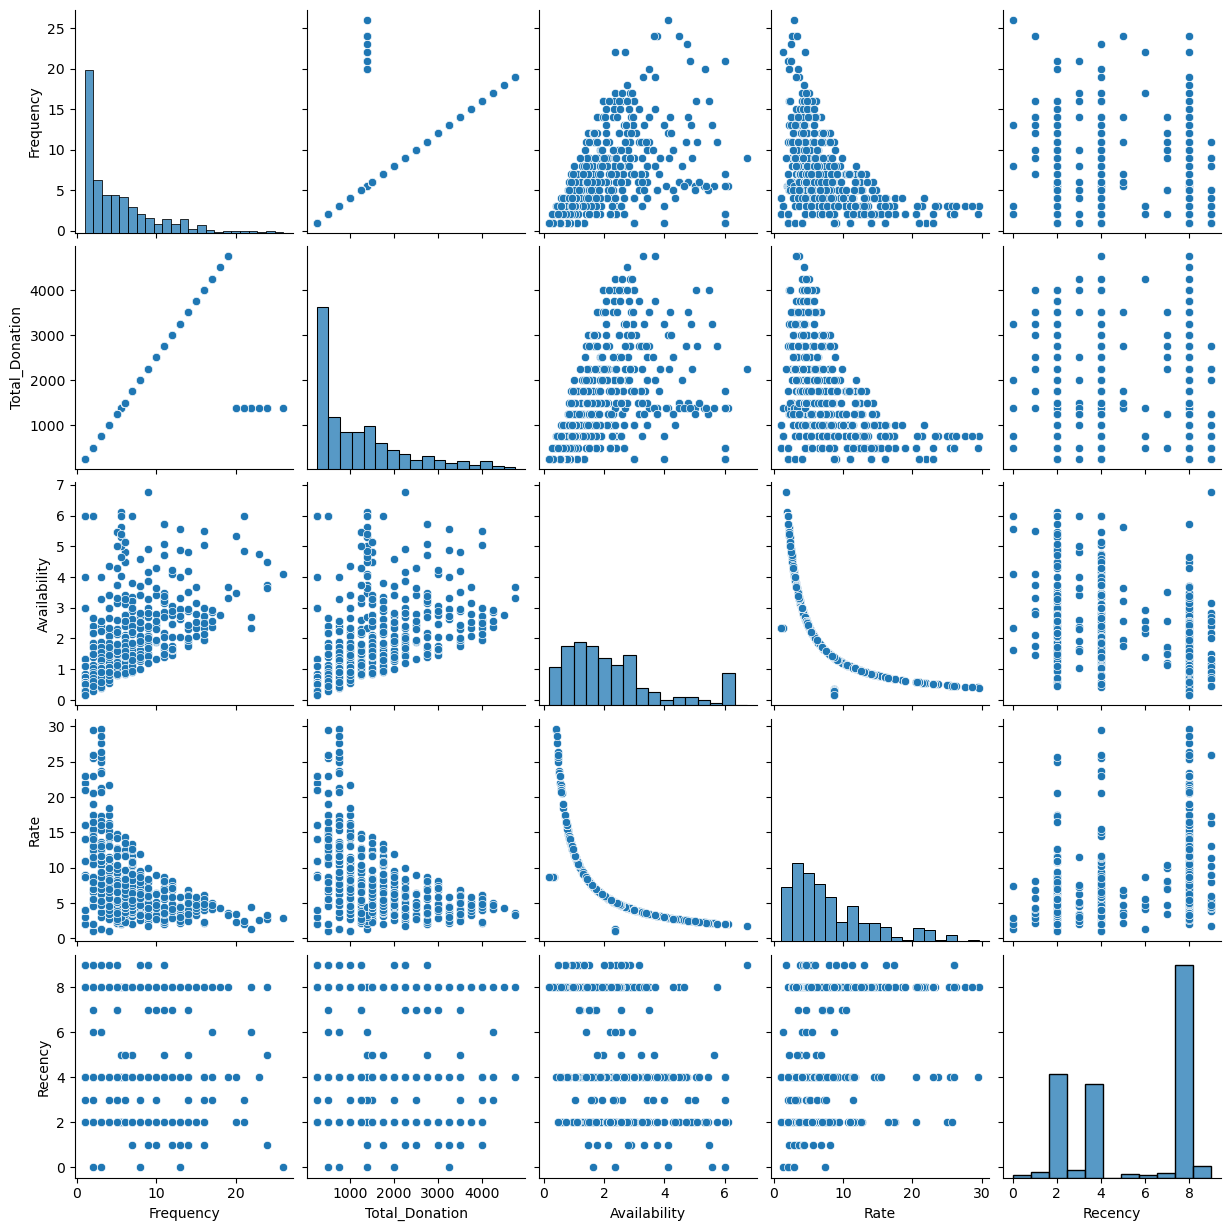

In [34]:
#%%
# Pair plot
selected_columns = ['Frequency', 'Total_Donation', 'Availability', 'Rate', 'Recency'] 
sns.pairplot(df[selected_columns]) 
plt.show()

In [35]:
#label Encoding

# le=LabelEncoder()
# df.Readiness=le.fit_transform(dt["Readiness"])

# df.hist(figsize=(20,20))

le=LabelEncoder()
df.Readiness=le.fit_transform(dt["Readiness"])
df.Available_Now = le.fit_transform(dt["Available_Now"])

array([[<Axes: title={'center': 'Frequency'}>,
        <Axes: title={'center': 'Total_Donation'}>,
        <Axes: title={'center': 'Availability'}>],
       [<Axes: title={'center': 'Rate'}>,
        <Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Readiness'}>],
       [<Axes: title={'center': 'Available_Now'}>, <Axes: >, <Axes: >]],
      dtype=object)

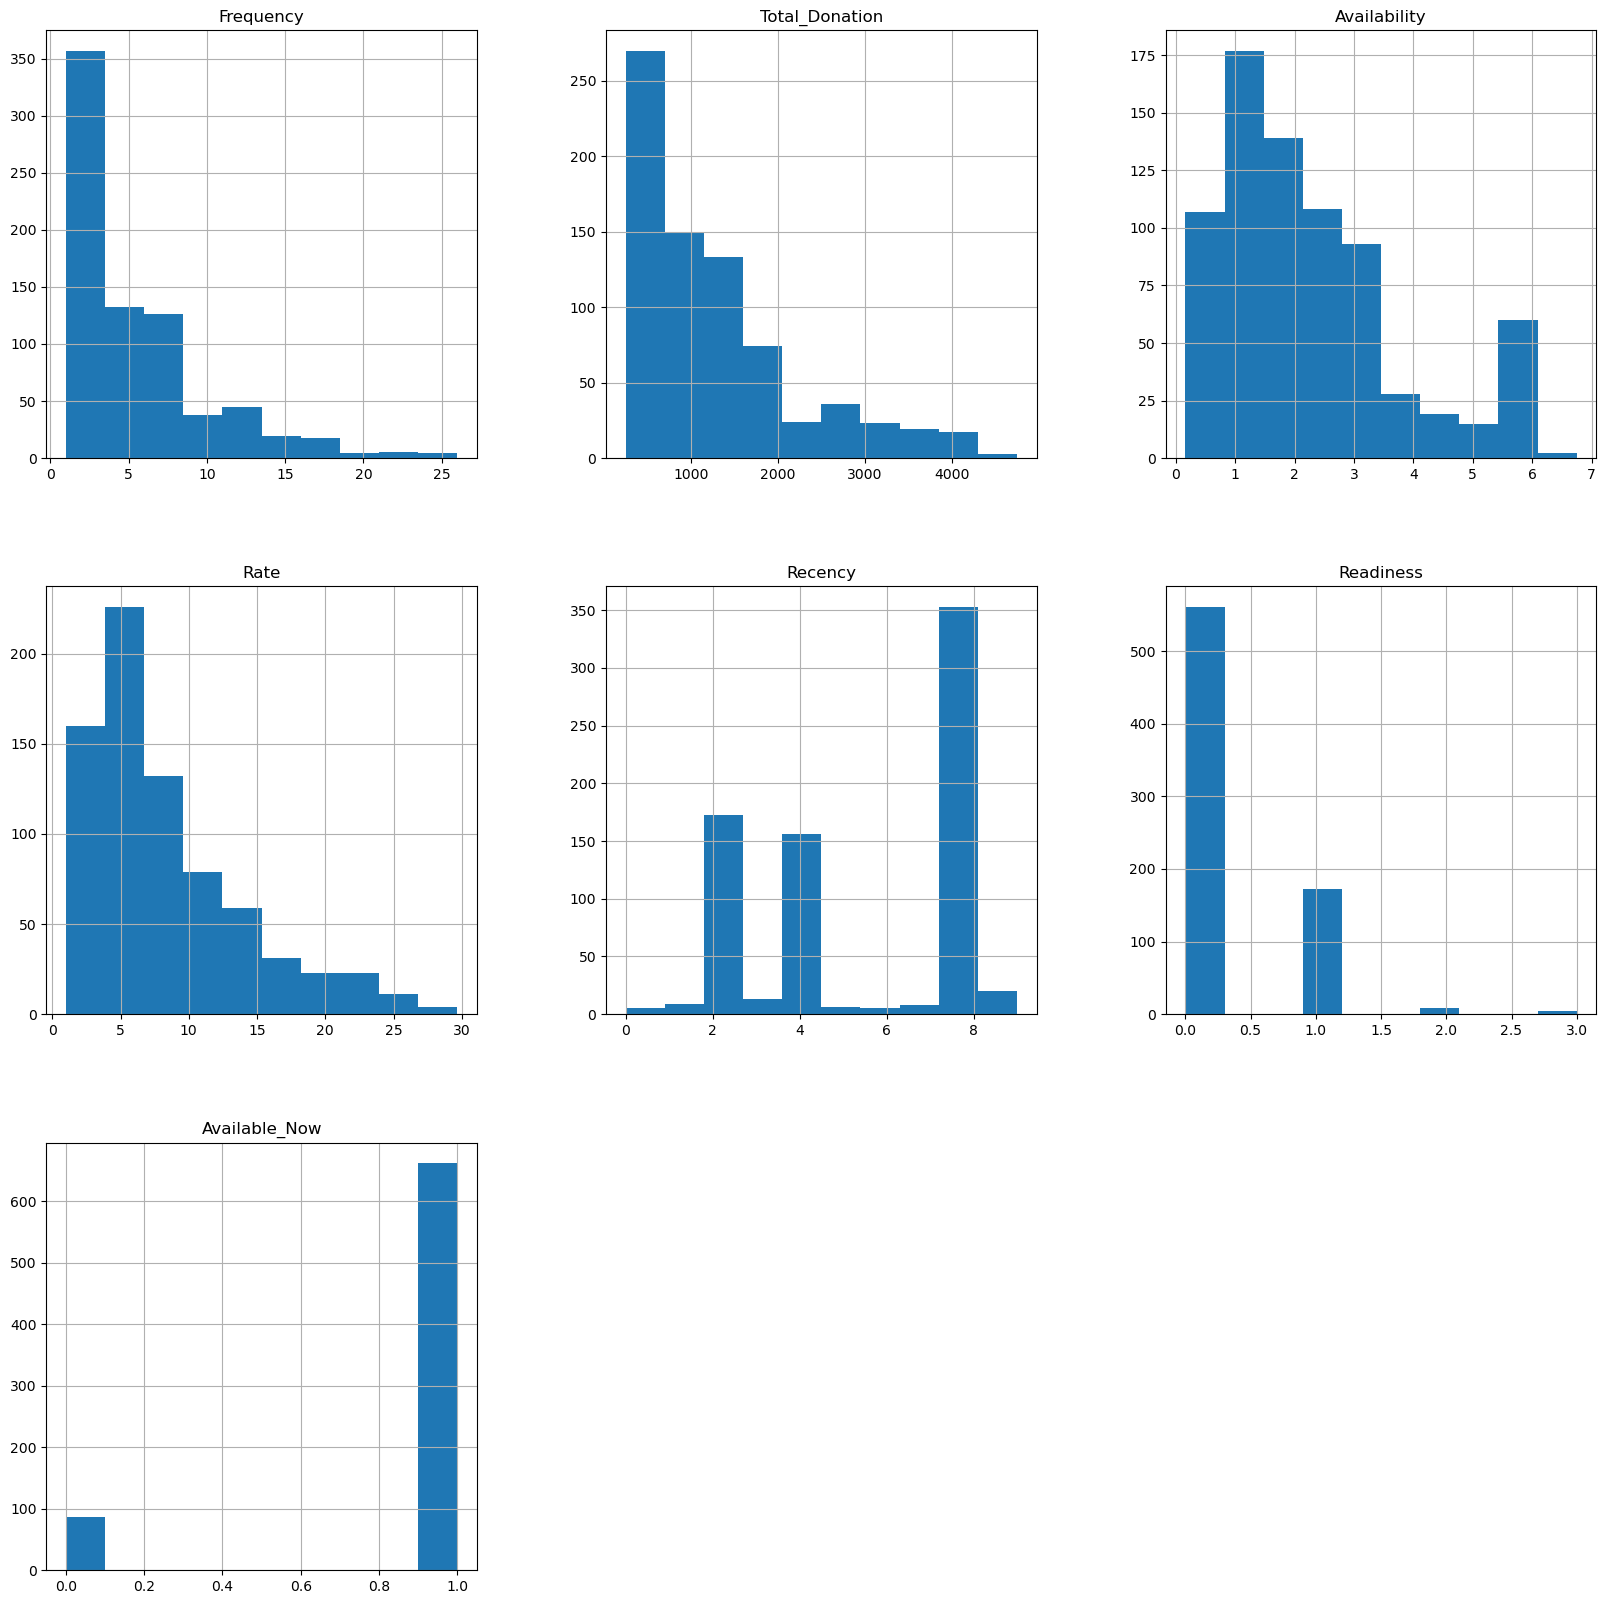

In [36]:
df.hist(figsize=(20,20))

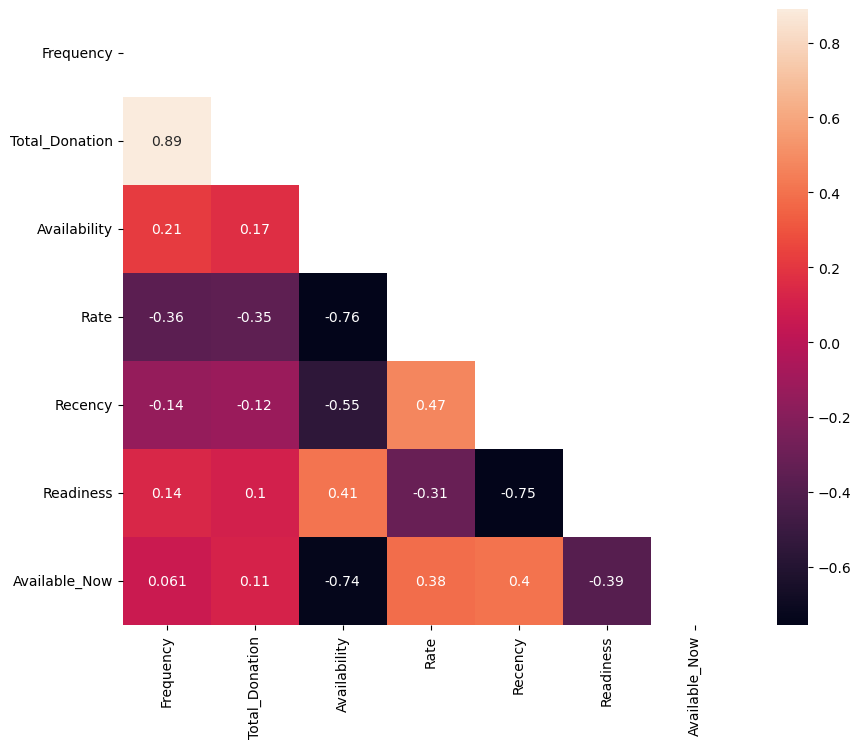

In [37]:
# Correlation measure and drop irrevelant column
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10,8)) # Set the figure size
sns.heatmap(corr_matrix, mask=mask, square=True, annot=True)
plt.show()

In [38]:
# dropping the following columns: 'Frequency', 'Total_Donation'
# new dataframe, df2
df.columns


Index(['Frequency', 'Total_Donation', 'Availability', 'Rate', 'Recency',
       'Readiness', 'Available_Now'],
      dtype='object')

In [39]:
df.columns
df2 = df[['Availability', 'Rate', 'Recency', 'Readiness', 'Available_Now']]

In [40]:
df2

,Availability,Rate,Recency,Readiness,Available_Now
0,6.122449,1.960000,2.0,1,0
1,5.571429,2.153846,0.0,3,0
2,5.485714,2.187500,1.0,2,0
3,5.333333,2.250000,2.0,1,0
4,3.740260,3.208333,1.0,2,1
...,...,...,...,...,...
743,0.631579,19.000000,8.0,0,1
744,0.461538,26.000000,8.0,0,1
745,0.580645,20.666667,8.0,0,1
746,0.307692,8.710695,8.0,0,1


In [41]:
# df2 = df[['Availability', 'Rate', 'Recency', 'Readiness', 'Available_Now']].copy

In [42]:
df2

,Availability,Rate,Recency,Readiness,Available_Now
0,6.122449,1.960000,2.0,1,0
1,5.571429,2.153846,0.0,3,0
2,5.485714,2.187500,1.0,2,0
3,5.333333,2.250000,2.0,1,0
4,3.740260,3.208333,1.0,2,1
...,...,...,...,...,...
743,0.631579,19.000000,8.0,0,1
744,0.461538,26.000000,8.0,0,1
745,0.580645,20.666667,8.0,0,1
746,0.307692,8.710695,8.0,0,1


In [43]:
# model building
# independent: 'Availability', 'Rate', 'Recency'
# dependent: 'Readiness'

# model: for Readiness
# Target column selcetion and split the dataset

In [44]:
scaler = StandardScaler()
scaler.fit(df2)

StandardScaler()

In [45]:
X=df2.drop(['Readiness', 'Available_Now'], axis=1)
y=df2["Readiness"]

# # X = df2.drop(columns = 'Readiness', 'Available_Now').values
# y = df2["Readiness"].values

In [46]:
X

,Availability,Rate,Recency
0,6.122449,1.960000,2.0
1,5.571429,2.153846,0.0
2,5.485714,2.187500,1.0
3,5.333333,2.250000,2.0
4,3.740260,3.208333,1.0
...,...,...,...
743,0.631579,19.000000,8.0
744,0.461538,26.000000,8.0
745,0.580645,20.666667,8.0
746,0.307692,8.710695,8.0


In [47]:
y

0      1
1      3
2      2
3      1
4      2
      ..
743    0
744    0
745    0
746    0
747    0
Name: Readiness, Length: 748, dtype: int32

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((523, 3), (225, 3), (523,), (225,))

In [49]:
#%%
# Training model

In [50]:
# Linear Regression
lnr = LinearRegression()
# fit the model to the training data
lnr.fit(X_train, y_train)
# make predictions on the testing data
y_pred = lnr.predict(X_test)
# calculate R2 score
lnr_r2 = r2_score(y_test, y_pred)
print('R2 score:', lnr_r2)


R2 score: 0.5713717640759501


In [51]:
# R2 score for Linear Regression: 0.5713717640759501

In [52]:
#%%
# Logistic Regression
lgr = LogisticRegression(max_iter=1000, C=1.0)
lgr.fit(X_train, y_train)

# make predictions on the testing data
y_pred = lgr.predict(X_test)

# calculate R2 score
lgr_r2 = r2_score(y_test, y_pred)
print('R2 score:',lgr_r2)


R2 score: 0.9096820809248555


In [53]:
# R2 score for Logistic Regression: 0.9096820809248555

In [54]:
#%%
# Ridge regression
ridge = Ridge()
# fit the model to the training data
ridge.fit(X_train, y_train)
# make predictions on the testing data
y_pred = ridge.predict(X_test)
# calculate R2 score
ridge_r2 = r2_score(y_test, y_pred)
print('R2 score:', ridge_r2)

# R2 score for Ridge Regression: 0.5713799300892675 (same with Linear regression)


R2 score: 0.5713799300892675


In [55]:
#%%
# Lasso regression
lasso=Lasso()
# fit the model to the training data
lasso.fit(X_train, y_train)
# make predictions on the testing data
y_pred = lasso.predict(X_test)
# calculate R2 score
lasso_r2 = r2_score(y_test, y_pred)
print('R2 score:', lasso_r2)

# R2 score for Lasso regression: 0.056476197325926125 (very poor)


R2 score: 0.056476197325926125


In [56]:
#%%
# Decision Tree Regressor
Dectree=DecisionTreeRegressor()
Dectree.fit(X_train, y_train)
# make predictions on the testing data
y_pred = Dectree.predict(X_test)
# calculate R2 score
Dectree_r2 = r2_score(y_test, y_pred)
print('R2 score:', Dectree_r2)

# R2 score for Decision Tree Regressor: 1.0 (overfiting)

R2 score: 1.0


In [57]:
#%%
# Random Forest Regressor
RFR=RandomForestRegressor()
RFR.fit(X_train, y_train)
# make predictions on the testing data
y_pred = RFR.predict(X_test)
# calculate R2 score
RFR_r2 = r2_score(y_test, y_pred)
print('R2 score:',RFR_r2)

# R2 score for Random Forest Regressor: 0.9993551300578035 (overfitting)


R2 score: 0.9994598988439306


In [58]:
#%%
# selected model: Logistic Regression: 0.9096820809248555
# Logistic Regression
lgr = LogisticRegression(max_iter=1000, C=1.0)
lgr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [59]:
# make predictions on the testing data
y_pred = lgr.predict(X_test)

# calculate R2 score
lgr_r2 = r2_score(y_test, y_pred)
print('R2 score:',lgr_r2)

R2 score: 0.9096820809248555


In [60]:
# R2 score for Logistic Regression: 0.9096820809248555

In [61]:
#%%
# performance matrix for Logistic Regression
# calculate mean squared error
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)

Mean Squared Error: 0.022222222222222223


In [62]:
# calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)


Mean Absolute Error: 0.022222222222222223


In [63]:
score = lgr.score(X_test, y_test)
print('Test Accuracy Score', score)

Test Accuracy Score 0.9777777777777777


In [64]:
c_report = classification_report(y_test, y_pred)
print('Classification Report\n', c_report )


Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           1       0.91      1.00      0.95        53
           2       0.00      0.00      0.00         5

    accuracy                           0.98       225
   macro avg       0.64      0.67      0.65       225
weighted avg       0.96      0.98      0.97       225



D:\anacoda install\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\anacoda install\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\anacoda install\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [65]:
#%%
# custom prediction
pred_value = lgr.predict([[6,  2, 2]])
print(pred_value)

[1]


D:\anacoda install\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
